In [1]:
import tensorflow as tf
import os

# Display TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
print(f"Number of available GPUs: {len(gpus)}")
for gpu in gpus:
    print(f"  GPU name: {gpu.name}, type: {gpu.device_type}")

# Try to get more detailed GPU information
if len(gpus) > 0:
    # Display CUDA version
    if hasattr(tf.sysconfig, 'get_build_info'):
        build_info = tf.sysconfig.get_build_info()
        print(f"CUDA version: {build_info.get('cuda_version', 'Unknown')}")
    else:
        print("Unable to get CUDA version through TensorFlow API")
    
    # Check CUDA environment variables using os.environ
    cuda_path = os.environ.get('CUDA_PATH', 'Not set')
    print(f"CUDA path environment variable: {cuda_path}")
    
    # Execute a simple GPU operation to confirm GPU is usable
    try:
        with tf.device('/GPU:0'):
            x = tf.random.normal([1000, 1000])
            y = tf.random.normal([1000, 1000])
            z = tf.matmul(x, y)
        print("GPU test successful: Completed a 1000x1000 matrix multiplication")
    except Exception as e:
        print(f"GPU test failed: {e}")
else:
    print("No GPU detected, TensorFlow will run on CPU")

# Show if TensorFlow is GPU version
if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA")
else:
    print("TensorFlow is not GPU version")

# Check if TensorFlow can see CUDA
print(f"TensorFlow can see CUDA: {tf.test.is_built_with_cuda()}")
print(f"CUDA is available: {tf.test.is_gpu_available(cuda_only=True)}")

2025-04-14 11:59:16.753228: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow版本: 2.9.0
可用的GPU数量: 1
  GPU名称: /physical_device:GPU:0, 类型: GPU
CUDA版本: 11.2
CUDA路径环境变量: 未设置


2025-04-14 11:59:18.309323: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-14 11:59:19.133763: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22167 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 D, pci bus id: 0000:39:00.0, compute capability: 8.9


GPU测试成功: 完成了一个1000x1000矩阵乘法运算
TensorFlow已使用CUDA构建
TensorFlow是否能够看到CUDA: True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
CUDA是否可用: True


2025-04-14 11:59:20.174039: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-04-14 11:59:20.177587: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 22167 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 D, pci bus id: 0000:39:00.0, compute capability: 8.9


In [2]:
import tensorflow as tf

# Check if GPU is available
physical_devices = tf.config.list_physical_devices('GPU')
print("Physical GPU devices:", physical_devices)

if len(physical_devices) > 0:
    try:
        # RTX 4090 configuration (16GB) - Reduce memory limit
        tf.config.set_logical_device_configuration(
            physical_devices[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=1024 * 16)]  # 16GB
        )
        print("GPU memory limit set successfully")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")

物理GPU设备: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU配置错误: Virtual devices cannot be modified after being initialized


In [3]:
#Importing libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
import os
import shutil
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score


In [4]:
CONFIGURATION = {
    'MODEL_NAME': 'ViT',
    'ZOOM': 200, # 40 / 100 / 200  400  -> Number of images: 1995 + 2081 + 2013 + 1820 100
    'DATA_SPLIT': 'custom', # original / custom
    'N_EPOCHS': 200,
    'BATCH_SIZE': 32, #64
    'IMAGE_SIZE': 160,
    'PATCH_SIZE': 16,
    'LR': 0.0001,
    'WEIGHT_DECAY': 0.001,
    'DROP_OUT': 0.7,
    'SPT': True, # Shifted Patch Tokenization 
}

## Load data

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data augmentation generator
data_gen = ImageDataGenerator(
    rotation_range=90,  # Random rotation range
    zoom_range=0.1,  # Random zoom range
    width_shift_range=0.1,  # Horizontal shift range
    height_shift_range=0.1,  # Vertical shift range
    horizontal_flip=True,  # Random horizontal flip
    vertical_flip=True,  # Random vertical flip
    fill_mode='nearest'  # Fill mode
)


In [6]:
from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.over_sampling import RandomOverSampler

# Load and preprocess the dataset
df = pd.read_csv("/root/autodl-tmp/BreakHis/Folds.csv")
dataset = df.iloc[:7909, :]
dataset = dataset[dataset['mag'] == CONFIGURATION['ZOOM']]
dataset = dataset.rename(columns = {"filename":"path"})

# Extract filename, location and labels from path
dataset['filename'] = dataset['path'].apply(lambda x:x.split("/")[-1])
dataset["label"] = dataset['path'].apply(lambda x: x.split("/")[3])
dataset["sublabel"] = dataset['path'].apply(lambda x: x.split("/")[5])
dataset['file_loc'] = dataset['label'] + "_" + dataset['filename']

# Encode class labels: benign -> 0, malignant -> 1
dataset['class'] = dataset['label'].apply(lambda x: 0 if x =='benign' else 1)

# Split data based on configuration setting
if (CONFIGURATION['DATA_SPLIT'] == 'original'):
    print("Original Split")
    # Use predefined train/test split from dataset
    train_val_df = dataset[dataset['grp'] == 'train']
    test_df = dataset[dataset['grp'] == 'test']
    # Further split training data into train and validation sets
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=1)
    for train_index, validation_index in sss.split(train_val_df['path'], train_val_df['class']):
        train_df, val_df = train_val_df.iloc[train_index], train_val_df.iloc[validation_index]

    print("train_df shape: {}".format(train_df.shape))
    print("val_df shape: {}".format(val_df.shape))
    print("test_df shape: {}".format(test_df.shape))
    
elif (CONFIGURATION['DATA_SPLIT'] == 'custom'):
    print("Custom split")
    # First split: 70% train, 30% validation+test
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=1)
    for train_index, validation_index in sss.split(dataset['path'], dataset['class']):
        train_df, val_test_df = dataset.iloc[train_index], dataset.iloc[validation_index]
    # Second split: Split remaining 30% into validation and test sets
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.67, random_state=1)
    for train_index, validation_index in sss.split(val_test_df['path'], val_test_df['class']):
        val_df, test_df = val_test_df.iloc[train_index], val_test_df.iloc[validation_index]
    
    print("train_df shape: {}".format(train_df.shape))
    print("val_df shape: {}".format(val_df.shape))
    print("test_df shape: {}".format(test_df.shape))

# Function to balance class distribution using random oversampling
def balance_attributes(target_df, attribute = 'class'):
  X = target_df.drop(attribute, axis=1)
  y = target_df[attribute]
  ros = RandomOverSampler(random_state=42)
  X_resampled, y_resampled = ros.fit_resample(X, y)
  balanced_labels_df = pd.concat([X_resampled, y_resampled], axis=1)

  return balanced_labels_df

train_df = balance_attributes(train_df)

# Function to load and preprocess image data with optional augmentation
def load_data(dataframe, augment=False):
    data_images = []
    data_labels = []
    for index, row in dataframe.iterrows():
        filename = "/root/autodl-tmp/BreakHis/BreaKHis_v1/" + row['path']
        image_class = row['class']

        # Read image
        img = cv2.imread(filename, cv2.IMREAD_COLOR)
        if img is None:
            print(f"Failed to read image: {filename}")
            continue
            
        # Preprocess image
        img = cv2.resize(img, (CONFIGURATION['IMAGE_SIZE'], CONFIGURATION['IMAGE_SIZE']))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0
        
        # Apply data augmentation if needed
        if augment:
            img = data_gen.random_transform(img)
            
        data_images.append(img)
        data_labels.append([image_class])
    
    # Check if any images were loaded
    if not data_images:
        raise ValueError("No images were successfully loaded")
            
    return np.array(data_images, dtype="float"),  np.array(data_labels)

# Load datasets - only apply augmentation to training set
training_images, training_labels = load_data(train_df, augment=True)
val_images, val_labels = load_data(val_df, augment=False)
test_images, test_labels = load_data(test_df, augment=False)

Custom split
train_df shape: (1409, 9)
val_df shape: (199, 9)
test_df shape: (405, 9)


In [7]:
training_images.shape[0]

1946

In [13]:
# Add after load_data function call
def validate_data(images, labels, set_name):
    print(f"\n{set_name} Data Validation:")
    print(f"Number of Images: {len(images)}")
    print(f"Image Shape: {images.shape}")
    print(f"Label Shape: {labels.shape}")
    print(f"Image Value Range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label Distribution:\n{np.unique(labels, return_counts=True)}")

# Validate all datasets
validate_data(training_images, training_labels, "Training Set")
validate_data(val_images, val_labels, "Validation Set") 
validate_data(test_images, test_labels, "Test Set")


训练集 数据验证:
图像数量: 1946
图像形状: (1946, 160, 160, 3)
标签形状: (1946, 1)
图像数值范围: [0.001, 1.000]
标签分布:
(array([0, 1]), array([973, 973]))

验证集 数据验证:
图像数量: 199
图像形状: (199, 160, 160, 3)
标签形状: (199, 1)
图像数值范围: [0.020, 1.000]
标签分布:
(array([0, 1]), array([ 62, 137]))

测试集 数据验证:
图像数量: 405
图像形状: (405, 160, 160, 3)
标签形状: (405, 1)
图像数值范围: [0.012, 1.000]
标签分布:
(array([0, 1]), array([125, 280]))


The shape of dataset images: (1946, 160, 160, 3)
The shape of dataset labels: (1946, 1)
图像数值范围： 0.08550050854682922 - 1.0
The first image of dataset:


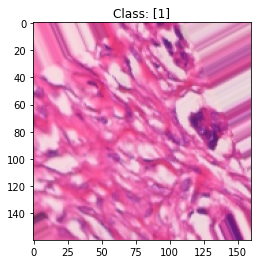

The shape of dataset images: (199, 160, 160, 3)
The shape of dataset labels: (199, 1)
图像数值范围： 0.41960784792900085 - 0.9333333373069763
The first image of dataset:


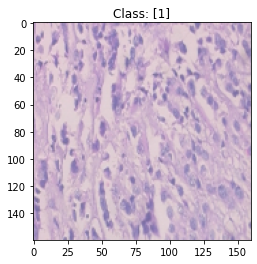

The shape of dataset images: (405, 160, 160, 3)
The shape of dataset labels: (405, 1)
图像数值范围： 0.4156862795352936 - 1.0
The first image of dataset:


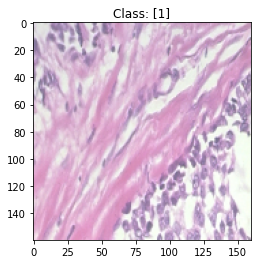

In [14]:
def check_data(images, labels):
    # Print basic information about the dataset
    print("The shape of dataset images:", images.shape)
    print("The shape of dataset labels:", labels.shape)
    print("Image value range:", np.min(images[0]), "-", np.max(images[0]))  
    
    # Display the first image with its label
    print("The first image of dataset:")
    plt.title("Class: " + str(labels[0]))
    plt.imshow(images[0])
    plt.show()

# Check training, validation and test datasets
check_data(training_images, training_labels)
check_data(val_images, val_labels)
check_data(test_images, test_labels)

## Model training

In [15]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
# import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from tensorflow.keras import layers


# Setting seed for reproducibiltiy
SEED = 42
keras.utils.set_random_seed(SEED)

NUM_CLASSES = 2
INPUT_SHAPE = (CONFIGURATION['IMAGE_SIZE'], CONFIGURATION['IMAGE_SIZE'], 3)

# DATA
BATCH_SIZE = CONFIGURATION['BATCH_SIZE']

# AUGMENTATION
IMAGE_SIZE = CONFIGURATION['IMAGE_SIZE']
PATCH_SIZE = CONFIGURATION['PATCH_SIZE']
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

# OPTIMIZER
LEARNING_RATE = CONFIGURATION['LR']
WEIGHT_DECAY = CONFIGURATION['WEIGHT_DECAY']

# TRAINING
EPOCHS = CONFIGURATION['N_EPOCHS']

# ARCHITECTURE  
LAYER_NORM_EPS = 1e-6
TRANSFORMER_LAYERS = 6
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM,
]
MLP_HEAD_UNITS = [512, 128]





In [16]:
class ShiftedPatchTokenization(layers.Layer):
    def __init__(
        self,
        image_size,
        patch_size,
        num_patches,
        projection_dim,
        vanilla=False,
        name=None,  # Add name parameter
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)
        self.image_size = image_size
        self.patch_size = patch_size
        self.half_patch = patch_size // 2
        self.projection_dim = projection_dim
        self.num_patches = num_patches
        self.vanilla = vanilla
        
        # Add unique names for all internal layers
        # For batch normalization of image patches
        self.patch_norm = layers.BatchNormalization(
            name=f"{name}_patch_norm" if name else "patch_norm"
        )
        
        # First projection layer with GELU activation to map patch features to projection_dim
        self.patch_proj_1 = layers.Dense(
            projection_dim, 
            activation='gelu',
            kernel_regularizer=regularizers.l2(1e-4),
            name=f"{name}_patch_proj_1" if name else "patch_proj_1"
        )
        
        # Second projection layer for further feature processing
        self.patch_proj_2 = layers.Dense(
            projection_dim,
            kernel_regularizer=regularizers.l2(1e-4),
            name=f"{name}_patch_proj_2" if name else "patch_proj_2"
        )
        
        # Dropout layer to prevent overfitting
        self.patch_dropout = layers.Dropout(
            0.1,
            name=f"{name}_patch_dropout" if name else "patch_dropout"
        )
        
        # Layer normalization for training stability
        self.patch_layer_norm = layers.LayerNormalization(
            epsilon=LAYER_NORM_EPS,
            name=f"{name}_patch_layer_norm" if name else "patch_layer_norm"
        )

    def extract_patches(self, images):
        # Add noise to input images for regularization
        noise = tf.random.normal(
            shape=tf.shape(images), 
            mean=0.0, 
            stddev=0.01,
            name="patch_noise"
        )
        images = images + noise
        
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patches = tf.reshape(patches, [tf.shape(images)[0], -1, self.patch_size * self.patch_size * 3])
        return patches

    def call(self, images, training=None):
        if self.vanilla:
            # Standard patch processing without shifting
            patches = self.extract_patches(images)
            patches = self.patch_norm(patches, training=training)
            patches = self.patch_proj_1(patches)
            patches = self.patch_dropout(patches, training=training)
            patches = self.patch_layer_norm(patches)
        else:
            # Process original patches
            patches = self.extract_patches(images)
            patches = self.patch_norm(patches, training=training)
            patches = self.patch_proj_1(patches)
            
            # Process shifted patches
            shifted_images = tf.roll(
                images, 
                shift=[self.half_patch, self.half_patch], 
                axis=[1, 2],
                name="shifted_images"
            )
            shifted_patches = self.extract_patches(shifted_images)
            shifted_patches = self.patch_norm(shifted_patches, training=training)
            shifted_patches = self.patch_proj_1(shifted_patches)
            
            # Attention fusion between original and shifted patches
            attention_weights = tf.nn.softmax(
                tf.matmul(patches, shifted_patches, transpose_b=True),
                name="attention_weights"
            )
            attention_output = tf.matmul(attention_weights, shifted_patches)
            
            # Concatenate original and attention-weighted patches
            patches = tf.concat(
                [patches, attention_output], 
                axis=1,
                name="concat_patches"
            )
            
            # Trim patches if needed
            patches = tf.cond(
                tf.greater(tf.shape(patches)[1], self.num_patches),
                lambda: patches[:, :self.num_patches, :],
                lambda: patches
            )
            
            patches = self.patch_dropout(patches, training=training)
            patches = self.patch_proj_2(patches)
            patches = self.patch_layer_norm(patches)
        
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "image_size": self.image_size,
            "patch_size": self.patch_size,
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
            "vanilla": self.vanilla,
        })
        return config

In [17]:
# 1. EfficientNetV2 Bottleneck
def bottleneck0(inputs):
    # Load pretrained EfficientNetV2 backbone network
    backbone = tf.keras.applications.EfficientNetV2B0(
        weights='imagenet', 
        include_top=False,
        input_tensor=inputs  # Directly specify input tensor
    )
    
    # Feature extraction and processing
    x = backbone.output  # Use backbone output
    x = layers.GlobalAveragePooling2D(
        name='efficient_gap'
    )(x)
    x = layers.BatchNormalization(
        name='efficient_bn'
    )(x)
    x = layers.Dense(
        256, 
        activation='relu',
        name='efficient_dense'
    )(x)
    x = layers.Flatten(
        name='efficient_flatten'
    )(x)
    
    return x

# 2. Neck Section
def neck_section(inputs):
    # Additional feature processing layers
    x = layers.Conv2D(256, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = layers.Flatten()(x)
    return x


# Create temporary model to print structure
def print_bottleneck0_structure():
    inputs = layers.Input(shape=(224, 224, 3))  # Assume input size is 224x224x3
    outputs = bottleneck0(inputs)
    temp_model = tf.keras.Model(inputs=inputs, outputs=outputs)
    temp_model.summary()

# Call function to print structure
print_bottleneck0_structure()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  0           ['rescaling[0][0]']              
                                                                                                  
 stem_conv (Conv2D)             (None, 112, 112, 32  864         ['normalization[0][0]']      

In [18]:
def bottleneck_resnet(inputs, model_name='ResNet50'):
    

    backbone = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    # Feature extraction and processing
    x = backbone.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Flatten()(x)
    return x



In [20]:
class PatchEncoder(layers.Layer):
    def __init__(
        self,
        num_patches,
        projection_dim,
        name=None,
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        
        # Create embedding layer for positional encoding
        self.pos_embedding = layers.Embedding(
            input_dim=num_patches, 
            output_dim=projection_dim,
            name=f"{name}_pos_embedding" if name else "pos_embedding"
        )

    def call(self, patch_input):  # patch_input: tensor of patch features
        # Generate sequential position indices (0 to num_patches-1)
        position_indices = tf.range(
            start=0, 
            limit=self.num_patches, 
            delta=1,
            name="position_indices"
        )
        
        # Get positional encodings from embedding layer
        position_encodings = self.pos_embedding(position_indices)
        
        # Add positional encodings to patch features
        encoded_patches = patch_input + position_encodings
        
        return encoded_patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim
        })
        return config

In [21]:
class MultiHeadAttentionLSA(tf.keras.layers.MultiHeadAttention):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        # Initialize learnable temperature parameter for LSA
        self.lsa_temperature = tf.Variable(
            math.sqrt(float(self._key_dim)), 
            trainable=True,
            name=f"{name}_lsa_temperature" if name else "lsa_temperature"
        )

    def _compute_attention(
        self, 
        query_tensor, 
        key_tensor, 
        value_tensor, 
        attention_mask=None, 
        training=None
    ):
        # Scale query by learnable temperature
        lsa_scaled_query = tf.multiply(
            query_tensor, 
            1.0 / self.lsa_temperature,
            name="lsa_scaled_query"
        )
        
        # Compute attention scores between key and scaled query
        lsa_raw_attention_scores = tf.einsum(
            self._dot_product_equation, 
            key_tensor, 
            lsa_scaled_query,
            name="lsa_raw_attention_scores"
        )
        
        # Apply attention mask and softmax
        lsa_masked_scores = self._masked_softmax(
            lsa_raw_attention_scores, 
            attention_mask
        )
        
        # Apply dropout for regularization
        lsa_score_dropout = self._dropout_layer(
            lsa_masked_scores, 
            training=training
        )
        
        # Compute final attention output by combining with values
        lsa_attention_result = tf.einsum(
            self._combine_equation, 
            lsa_score_dropout, 
            value_tensor,
            name="lsa_attention_result"
        )
        
        return lsa_attention_result, lsa_masked_scores

    def get_config(self):
        base_config = super().get_config()
        # Add LSA temperature to config for serialization
        base_config.update({
            "lsa_temperature": self.lsa_temperature.numpy()
        })
        return base_config

In [22]:
def mlp(x, hidden_units, dropout_rate=0.1, name_prefix="mlp"):
    for i, units in enumerate(hidden_units):
        x = layers.Dense(
            units, 
            activation=tf.nn.gelu,
            name=f'{name_prefix}_dense_{i}'
        )(x)
        x = layers.Dropout(
            dropout_rate,
            name=f'{name_prefix}_dropout_{i}'
        )(x)
    return x

# Build the diagonal attention mask
diag_attn_mask = 1 - tf.eye(NUM_PATCHES)
diag_attn_mask = tf.cast([diag_attn_mask], dtype=tf.int8)


def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config    

In [23]:
def create_cnn_classifier():

    # Input layer accepting images of shape INPUT_SHAPE
    inputs = layers.Input(shape=INPUT_SHAPE)
    
    # Initial feature extraction using bottleneck layer
    x = bottleneck0(inputs)
    
    # First dense block with regularization and normalization
    x = layers.Dense(512, activation='relu', 
                    kernel_regularizer=regularizers.l2(CONFIGURATION['WEIGHT_DECAY']))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CONFIGURATION['DROP_OUT'])(x)
    
    # Second dense block with regularization and normalization
    x = layers.Dense(256, activation='relu', 
                    kernel_regularizer=regularizers.l2(CONFIGURATION['WEIGHT_DECAY']))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CONFIGURATION['DROP_OUT'])(x)
    
    # Output layer with softmax activation for classification
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    # Create and return the model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [24]:
def create_vit_classifier(vanilla=True):

    inputs = layers.Input(shape=INPUT_SHAPE, name='input_layer')
    
    # Extract and encode image patches
    patches = ShiftedPatchTokenization(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_patches=NUM_PATCHES * (2 if not vanilla else 1),
        projection_dim=PROJECTION_DIM,
        vanilla=vanilla,
        name='patch_extraction'
    )(inputs)
    
    encoded_patches = PatchEncoder(
        num_patches=NUM_PATCHES * (2 if not vanilla else 1),
        projection_dim=PROJECTION_DIM,
        name='patch_encoding'
    )(patches)
    
    # Process patches through transformer blocks
    for i in range(TRANSFORMER_LAYERS):
        # First LayerNorm
        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_{i}_norm1'
        )(encoded_patches)
        
        # Multi-head attention layer
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM,
            dropout=0.1,
            name=f'transformer_{i}_mha'
        )(x1, x1)
        
        # First residual connection
        x2 = layers.Add(name=f'transformer_{i}_add1')([attention_output, encoded_patches])
        
        # Second LayerNorm
        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_{i}_norm2'
        )(x2)
        
        # MLP block with unique name prefix
        x3 = mlp(
            x3,
            hidden_units=TRANSFORMER_UNITS,
            dropout_rate=0.1,
            name_prefix=f'transformer_{i}_mlp'
        )
        
        # Second residual connection
        encoded_patches = layers.Add(name=f'transformer_{i}_add2')([x3, x2])
    
    # Final processing
    representation = layers.LayerNormalization(
        epsilon=1e-6,
        name='final_norm'
    )(encoded_patches)
    representation = layers.GlobalAveragePooling1D(name='gap')(representation)
    
    # Classification head
    features = layers.Dense(
        PROJECTION_DIM, 
        activation='relu',
        name='pre_classifier'
    )(representation)
    features = layers.Dropout(0.1, name='final_dropout')(features)
    outputs = layers.Dense(
        NUM_CLASSES, 
        activation='softmax',
        name='classifier'
    )(features)
    
    return keras.Model(inputs=inputs, outputs=outputs)

In [25]:
def create_hybrid_classifier(use_spt=False):

    kernel_regularizer = regularizers.l2(CONFIGURATION['WEIGHT_DECAY'] * 0.5)
    
    inputs = layers.Input(shape=INPUT_SHAPE, name='input_layer')
    
    # EfficientNetV2 branch
    efficient_branch = bottleneck0(inputs)
    
    # Vision Transformer branch
    tokens = ShiftedPatchTokenization(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_patches=NUM_PATCHES * (2 if use_spt else 1),
        projection_dim=PROJECTION_DIM,
        vanilla=not use_spt,
        name='spt_layer'
    )(inputs)
    
    # Add positional encoding
    encoded_patches = PatchEncoder(
        num_patches=NUM_PATCHES * (2 if use_spt else 1),
        projection_dim=PROJECTION_DIM,
        name='patch_encoder'
    )(tokens)

    # Transformer encoder blocks
    for i in range(TRANSFORMER_LAYERS):
        # Layer normalization 1
        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_norm1_{i}'
        )(encoded_patches)
        
        # Multi-head attention with optional LSA
        if use_spt:
            attention_output = MultiHeadAttentionLSA(
                num_heads=NUM_HEADS, 
                key_dim=PROJECTION_DIM, 
                dropout=0.1,
                name=f'mha_lsa_{i}'
            )(x1, x1)
        else:
            attention_output = layers.MultiHeadAttention(
                num_heads=NUM_HEADS, 
                key_dim=PROJECTION_DIM, 
                dropout=0.1,
                name=f'mha_{i}'
            )(x1, x1)
            
        # Skip connection 1
        x2 = layers.Add(name=f'skip_connection1_{i}')([attention_output, encoded_patches])
        
        # Layer normalization 2
        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f'transformer_norm2_{i}'
        )(x2)
        
        # MLP block
        x3 = mlp(
            x3, 
            hidden_units=TRANSFORMER_UNITS, 
            dropout_rate=0.1,
            name_prefix=f'mlp_{i}'
        )
        
        # Skip connection 2
        encoded_patches = layers.Add(name=f'skip_connection2_{i}')([x3, x2])

    # Process ViT output
    vit_features = layers.LayerNormalization(
        epsilon=1e-6,
        name='final_layer_norm'
    )(encoded_patches)
    vit_features = layers.Flatten(name='flatten')(vit_features)
    vit_features = layers.Dropout(0.2, name='vit_dropout')(vit_features)
    
    # Merge features from both branches
    combined_features = layers.Concatenate(name='feature_concat')([efficient_branch, vit_features])
    
    # Classification layers
    x = layers.Dense(
        512, 
        activation='relu',
        kernel_regularizer=kernel_regularizer,
        activity_regularizer=regularizers.l1(1e-6),
        name='dense_1'
    )(combined_features)
    x = layers.BatchNormalization(momentum=0.9, name='bn_1')(x)
    x = layers.Dropout(0.2, name='dropout_1')(x)
    
    x = layers.Dense(
        256, 
        activation='relu',
        kernel_regularizer=kernel_regularizer,
        activity_regularizer=regularizers.l1(1e-6),
        name='dense_2'
    )(x)
    x = layers.BatchNormalization(momentum=0.9, name='bn_2')(x)
    x = layers.Dropout(0.2, name='dropout_2')(x)
    
    outputs = layers.Dense(
        NUM_CLASSES, 
        activation='softmax',
        kernel_regularizer=kernel_regularizer,
        name='output'
    )(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

In [26]:
# Create model instance
model = create_vit_classifier(vanilla=not CONFIGURATION['SPT'])

# Print model architecture summary
print("\nModel Architecture:")
print("=" * 80)
model.summary(line_length=80, show_trainable=True)

# Print detailed information for each layer
print("\nDetailed Layer Information:")
print("=" * 80)
for idx, layer in enumerate(model.layers):
    print(f"\nLayer {idx}: {layer.name}")
    print(f"Type: {type(layer).__name__}")
    print(f"Input Shape: {layer.input_shape}")
    print(f"Output Shape: {layer.output_shape}")
    print(f"Trainable: {layer.trainable}")
    print("-" * 40)

# Print model configuration statistics
print("\nModel Configuration:")
print("=" * 80)
print(f"Total Parameters: {model.count_params():,}")
print(f"Trainable Parameters: {sum([w.numpy().size for w in model.trainable_weights]):,}")
print(f"Non-trainable Parameters: {sum([w.numpy().size for w in model.non_trainable_weights]):,}")

def visualize_model(model, filename='model_architecture.png'):
    """
    Visualize and save model architecture as an image
    
    Args:
        model: Keras model instance to visualize
        filename: Output image filename
    """
    tf.keras.utils.plot_model(
        model,
        to_file=filename,
        show_shapes=True,      # Display shape info
        show_layer_names=True, # Display layer names  
        rankdir='TB',         # Top to bottom layout
        expand_nested=True,    # Expand nested models
        dpi=96,
        show_layer_activations=True  # Show activation functions
    )
    print(f"Model architecture has been saved to {filename}")

# Generate visualization
visualize_model(model)


Model Architecture:
Model: "model_1"
___________________________________________________________________________________________
 Layer (type)             Output Shape      Param #  Connected to               Trainable  
 input_layer (InputLayer)  [(None, 160, 160  0       []                         Y          
                          , 3)]                                                            
                                                                                           
 patch_extraction (Shifte  (None, None, 64)  56576   ['input_layer[0][0]']      Y          
 dPatchTokenization)                                                                       
                                                                                           
 patch_encoding (PatchEnc  (None, 200, 64)  12800    ['patch_extraction[0][0]'  Y          
 oder)                                               ]                                     
                                          

                                                                                           
 transformer_3_mha (Multi  (None, 200, 64)  66368    ['transformer_3_norm1[0][  Y          
 HeadAttention)                                      0]',                                  
                                                      'transformer_3_norm1[0][             
                                                     0]']                                  
                                                                                           
 transformer_3_add1 (Add)  (None, 200, 64)  0        ['transformer_3_mha[0][0]  Y          
                                                     ',                                    
                                                      'transformer_2_add2[0][0             
                                                     ]']                                   
                                                                                

In [27]:
# Import required libraries
import tensorflow as tf
from keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# Save the best model during training
checkpoint = ModelCheckpoint(
    "/root/autodl-tmp/Checkpoint/Hybrid_vit_spt.keras",
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,     # Only save model if validation accuracy improves
    verbose=1
)

# Stop training early if model performance plateaus
early_stopping = EarlyStopping(
    monitor='val_accuracy',        # Monitor validation accuracy
    patience=20,                   # Number of epochs to wait before stopping
    verbose=1,
    restore_best_weights=True,     # Restore model weights from the epoch with the best value
    mode='max'                     # Maximize validation accuracy
)

# Reduce learning rate when metrics plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',        # Monitor validation accuracy
    factor=0.1,                    # Factor to reduce learning rate by
    patience=5,                    # Number of epochs to wait before reducing LR
    mode='max',                    # Maximize validation accuracy
    min_lr=1e-7,                  # Minimum learning rate
    verbose=1
)

# Log training metrics to CSV file
csv_logger = CSVLogger(f"{CONFIGURATION['MODEL_NAME']}_model.log")

# Combine all callbacks
callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]

In [28]:

def get_metrics():
    return [keras.metrics.SparseCategoricalAccuracy(name="accuracy")]

def get_loss():
    return keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [29]:
import datetime
import os
import datetime

In [30]:
def run_experiment(model, model_name='hybrid_model', experiment_type=''):
    # Create base save path with timestamp
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    model_save_path = os.path.join(
        '/root/autodl-tmp/Checkpoint',
        f'{model_name}_{experiment_type}_{timestamp}'
    )
    os.makedirs(model_save_path, exist_ok=True)
    
    try:
        # Create training and validation datasets with batching and prefetching
        train_dataset = tf.data.Dataset.from_tensor_slices(
            (training_images, training_labels)
        ).batch(CONFIGURATION['BATCH_SIZE']).prefetch(tf.data.AUTOTUNE)
        
        val_dataset = tf.data.Dataset.from_tensor_slices(
            (val_images, val_labels)
        ).batch(CONFIGURATION['BATCH_SIZE']).prefetch(tf.data.AUTOTUNE)
        
        # Setup callbacks for model checkpointing and training optimization
        experiment_callbacks = [
            # Save best model in Keras format
            ModelCheckpoint(
                filepath=os.path.join(model_save_path, 'best_model.keras'),
                monitor='val_accuracy',
                save_best_only=True,
                save_format='keras',
                verbose=1,
                mode='max'
            ),
            # Save best model in H5 format
            ModelCheckpoint(
                filepath=os.path.join(model_save_path, 'best_model.h5'),
                monitor='val_accuracy',
                save_best_only=True,
                save_format='h5',
                verbose=1,
                mode='max'
            ),
            # Save best model in SavedModel format
            ModelCheckpoint(
                filepath=os.path.join(model_save_path, 'best_model'),
                monitor='val_accuracy',
                save_best_only=True,
                save_format='tf',
                verbose=1,
                mode='max'
            ),
            # Stop training if no improvement after patience epochs
            EarlyStopping(
                monitor='val_accuracy',
                patience=20,
                restore_best_weights=True,
                verbose=1,
                mode='max'
            ),
            # Reduce learning rate when accuracy plateaus
            ReduceLROnPlateau(
                monitor='val_accuracy',
                factor=0.1,
                patience=5,
                mode='max',
                min_lr=1e-7,
                verbose=1
            ),
            # Log training metrics to file
            CSVLogger(os.path.join(model_save_path, 'training.log'))
        ]
        
        # Compile model with optimizer and metrics
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIGURATION['LR']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model and return history
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=CONFIGURATION['N_EPOCHS'],
            callbacks=experiment_callbacks,
            verbose=1
        )
        
        return model, history
        
    except Exception as e:
        # Print debug info if error occurs
        print(f"Error occurred: {str(e)}")
        print(f"Current working directory: {os.getcwd()}")
        print(f"Attempted to save to: {model_save_path}")
        raise

In [31]:
# Print general configuration settings
print(f"Current configuration:")
print(f"SPT enabled: {CONFIGURATION['SPT']}")
print(f"Learning rate: {CONFIGURATION['LR']}")
print(f"Batch size: {CONFIGURATION['BATCH_SIZE']}")
print(f"Epochs: {CONFIGURATION['N_EPOCHS']}")

# Run hybrid model experiment with SPT
# Create hybrid classifier with SPT configuration
hybrid_vit_spt = create_hybrid_classifier(use_spt=CONFIGURATION['SPT'])

# Train model and get training history
model_spt, history_spt = run_experiment(
    hybrid_vit_spt, 
    model_name='vit',
    experiment_type='hybrid_spt'  # Identifier for experiment type
)

# Save final trained model
model.save('/root/autodl-tmp/Model_Weight/final_model_spt.keras')

Current configuration:
SPT enabled: True
Learning rate: 0.0001
Batch size: 32
Epochs: 200


Epoch 1/200


2025-04-14 12:00:32.801362: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-04-14 12:00:34.105309: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2025-04-14 12:00:34.105343: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2025-04-14 12:00:34.105439: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


61/61 [==============================] - ETA: 0s - loss: 1.5257 - accuracy: 0.6634
Epoch 1: val_accuracy improved from -inf to 0.29146, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model.keras

Epoch 1: val_accuracy improved from -inf to 0.29146, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model.h5

Epoch 1: val_accuracy improved from -inf to 0.29146, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model


INFO:tensorflow:Assets written to: /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model/assets


...

INFO:tensorflow:Assets written to: /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model/assets


61/61 [==============================] - 46s 774ms/step - loss: 0.8375 - accuracy: 0.9203 - val_loss: 0.8921 - val_accuracy: 0.9045 - lr: 1.0000e-05
Epoch 23/200
61/61 [==============================] - ETA: 0s - loss: 0.8340 - accuracy: 0.9147
Epoch 23: val_accuracy improved from 0.90452 to 0.91457, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model.keras

Epoch 23: val_accuracy improved from 0.90452 to 0.91457, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model.h5

Epoch 23: val_accuracy improved from 0.90452 to 0.91457, saving model to /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model


INFO:tensorflow:Assets written to: /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model/assets


INFO:tensorflow:Assets written to: /root/autodl-tmp/Checkpoint/vit_hybrid_spt_20250414_120013/best_model/assets


61/61 [==============================] - 46s 772ms/step - loss: 0.8340 - accuracy: 0.9147 - val_loss: 0.8943 - val_accuracy: 0.9146 - lr: 1.0000e-05
Epoch 24/200
61/61 [==============================] - ETA: 0s - loss: 0.8376 - accuracy: 0.9157
Epoch 24: val_accuracy did not improve from 0.91457

Epoch 24: val_accuracy did not improve from 0.91457

Epoch 24: val_accuracy did not improve from 0.91457
61/61 [==============================] - 7s 112ms/step - loss: 0.8376 - accuracy: 0.9157 - val_loss: 0.9020 - val_accuracy: 0.9095 - lr: 1.0000e-05
Epoch 25/200
61/61 [==============================] - ETA: 0s - loss: 0.8231 - accuracy: 0.9193
Epoch 25: val_accuracy did not improve from 0.91457

Epoch 25: val_accuracy did not improve from 0.91457

Epoch 25: val_accuracy did not improve from 0.91457
61/61 [==============================] - 7s 114ms/step - loss: 0.8231 - accuracy: 0.9193 - val_loss: 0.9054 - val_accuracy: 0.8794 - lr: 1.0000e-05
Epoch 26/200
61/61 [===========================

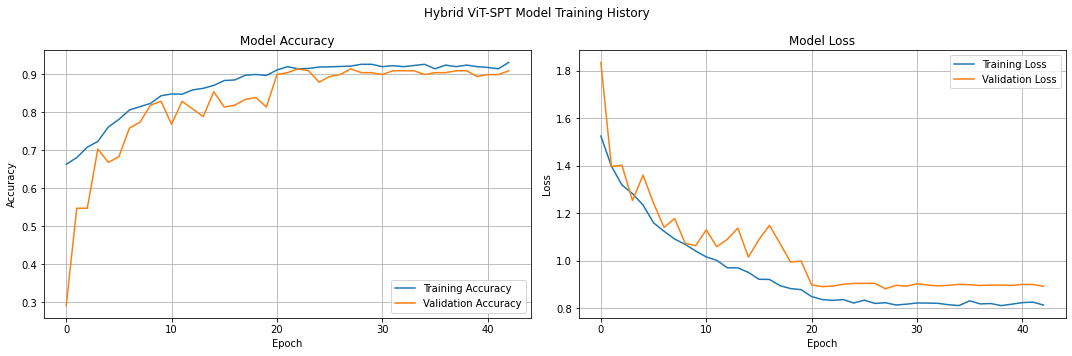


Final Training Metrics:
Training Accuracy: 0.9317
Validation Accuracy: 0.9095
Training Loss: 0.8145
Validation Loss: 0.8934


In [32]:
import matplotlib.pyplot as plt

def plot_training_history(history, title='Training History'):
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy curves
    # Left subplot shows training and validation accuracy over epochs
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.grid(True)
    
    # Plot loss curves
    # Right subplot shows training and validation loss over epochs
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')
    ax2.grid(True)
    
    # Set main title and adjust layout
    plt.suptitle(title)
    plt.tight_layout()
    
    # Display the plot
    plt.show()
    
    # Print final metrics from the last epoch
    print("\nFinal Training Metrics:")
    print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")

# Visualize training history for the hybrid ViT-SPT model
plot_training_history(history_spt, title='Hybrid ViT-SPT Model Training History')

In [ ]:
loss, accuracy= model_spt.evaluate(val_images, val_labels)
print(f"Val loss: {round(loss, 2)}")
print(f"Val accuracy: {round(accuracy * 100, 2)}%")

7/7 [==============================] - 4s 34ms/step - loss: 0.8939 - accuracy: 0.8995
Val loss: 0.89
Val accuracy: 89.95%


In [34]:
loss, accuracy= model_spt.evaluate(test_images, test_labels)
print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")

13/13 [==============================] - 1s 45ms/step - loss: 0.8627 - accuracy: 0.9210
Test loss: 0.86
Test accuracy: 92.1%


In [35]:
y_pred = model_spt.predict(test_images)

rounded_test_labels = test_labels.flatten()
rounded_predictions =  np.argmax(y_pred, axis=1)

13/13 [==============================] - 3s 33ms/step


In [36]:
#Classification report
print(classification_report(rounded_test_labels, rounded_predictions))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       125
           1       0.94      0.94      0.94       280

    accuracy                           0.91       405
   macro avg       0.90      0.90      0.90       405
weighted avg       0.91      0.91      0.91       405



In [ ]:
#Accuracy
accuracy = accuracy_score(rounded_test_labels, rounded_predictions)
print('Accuracy: %f' % accuracy)
#Precision
precision = precision_score(rounded_test_labels, rounded_predictions)
print('Precision: %f' % precision)
# Recall
recall = recall_score(rounded_test_labels, rounded_predictions, pos_label=1)
print('Recall: %f' % recall)
#Specificity 
specificity = recall_score(rounded_test_labels, rounded_predictions, pos_label=0)
print('Specificity: %f' % specificity)
#F1-score

F1_score = f1_score(rounded_test_labels, rounded_predictions)
print('F1_score: %f' % F1_score)

Accuracy: 0.913580
Precision: 0.935943
Recall: 0.939286
Specificity: 0.856000
F1_score: 0.937611


In [38]:
from tensorflow.keras.models import Model

def make_gradcam_heatmap(model, image_array, target_layer_name="top_conv", class_index=None):
    # Create model for Grad-CAM visualization
    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(target_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_array)
        if class_index is None:
            class_index = tf.argmax(predictions[0])
        class_output = predictions[:, class_index]

    # Calculate and process gradients
    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    
    # Generate normalized heatmap
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

In [39]:
import cv2
import matplotlib.pyplot as plt


def overlay_heatmap(heatmap, original_image, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay a heatmap on top of an original image
    
    Args:
        heatmap: The attention heatmap to overlay
        original_image: The base image
        alpha: Transparency of the heatmap overlay (0-1)
        colormap: Color scheme for the heatmap visualization
        
    Returns:
        overlayed: Image with heatmap overlaid on top
    """
    # Scale heatmap to 0-255 range
    heatmap = np.uint8(255 * heatmap)
    
    # Resize heatmap to match original image dimensions
    heatmap = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # Apply colormap to create colored heatmap
    colored = cv2.applyColorMap(heatmap, colormap)
    
    # Blend the colored heatmap with original image
    overlayed = cv2.addWeighted(colored, alpha, original_image, 1 - alpha, 0)
    return overlayed


Sample #1611
Original     → class 0 (score 1.000)
Masked (out) → class 0 (score 0.877)
Kept (only)  → class 1 (score 0.905)

Sample #1403
Original     → class 0 (score 1.000)
Masked (out) → class 0 (score 0.972)
Kept (only)  → class 0 (score 0.740)

Sample #974
Original     → class 1 (score 0.962)
Masked (out) → class 1 (score 0.862)
Kept (only)  → class 1 (score 0.768)



Sample #1055
Original     → class 1 (score 0.964)
Masked (out) → class 1 (score 0.587)
Kept (only)  → class 1 (score 0.860)

Sample #307
Original     → class 0 (score 1.000)
Masked (out) → class 0 (score 0.996)
Kept (only)  → class 0 (score 0.775)

Sample #432
Original     → class 1 (score 0.943)
Masked (out) → class 1 (score 0.922)
Kept (only)  → class 1 (score 0.717)

Sample #1464
Original     → class 0 (score 0.993)
Masked (out) → class 0 (score 0.932)
Kept (only)  → class 1 (score 0.656)

Sample #598
Original     → class 1 (score 0.810)
Masked (out) → class 1 (score 0.684)
Kept (only)  → class 1 (score 0.555)


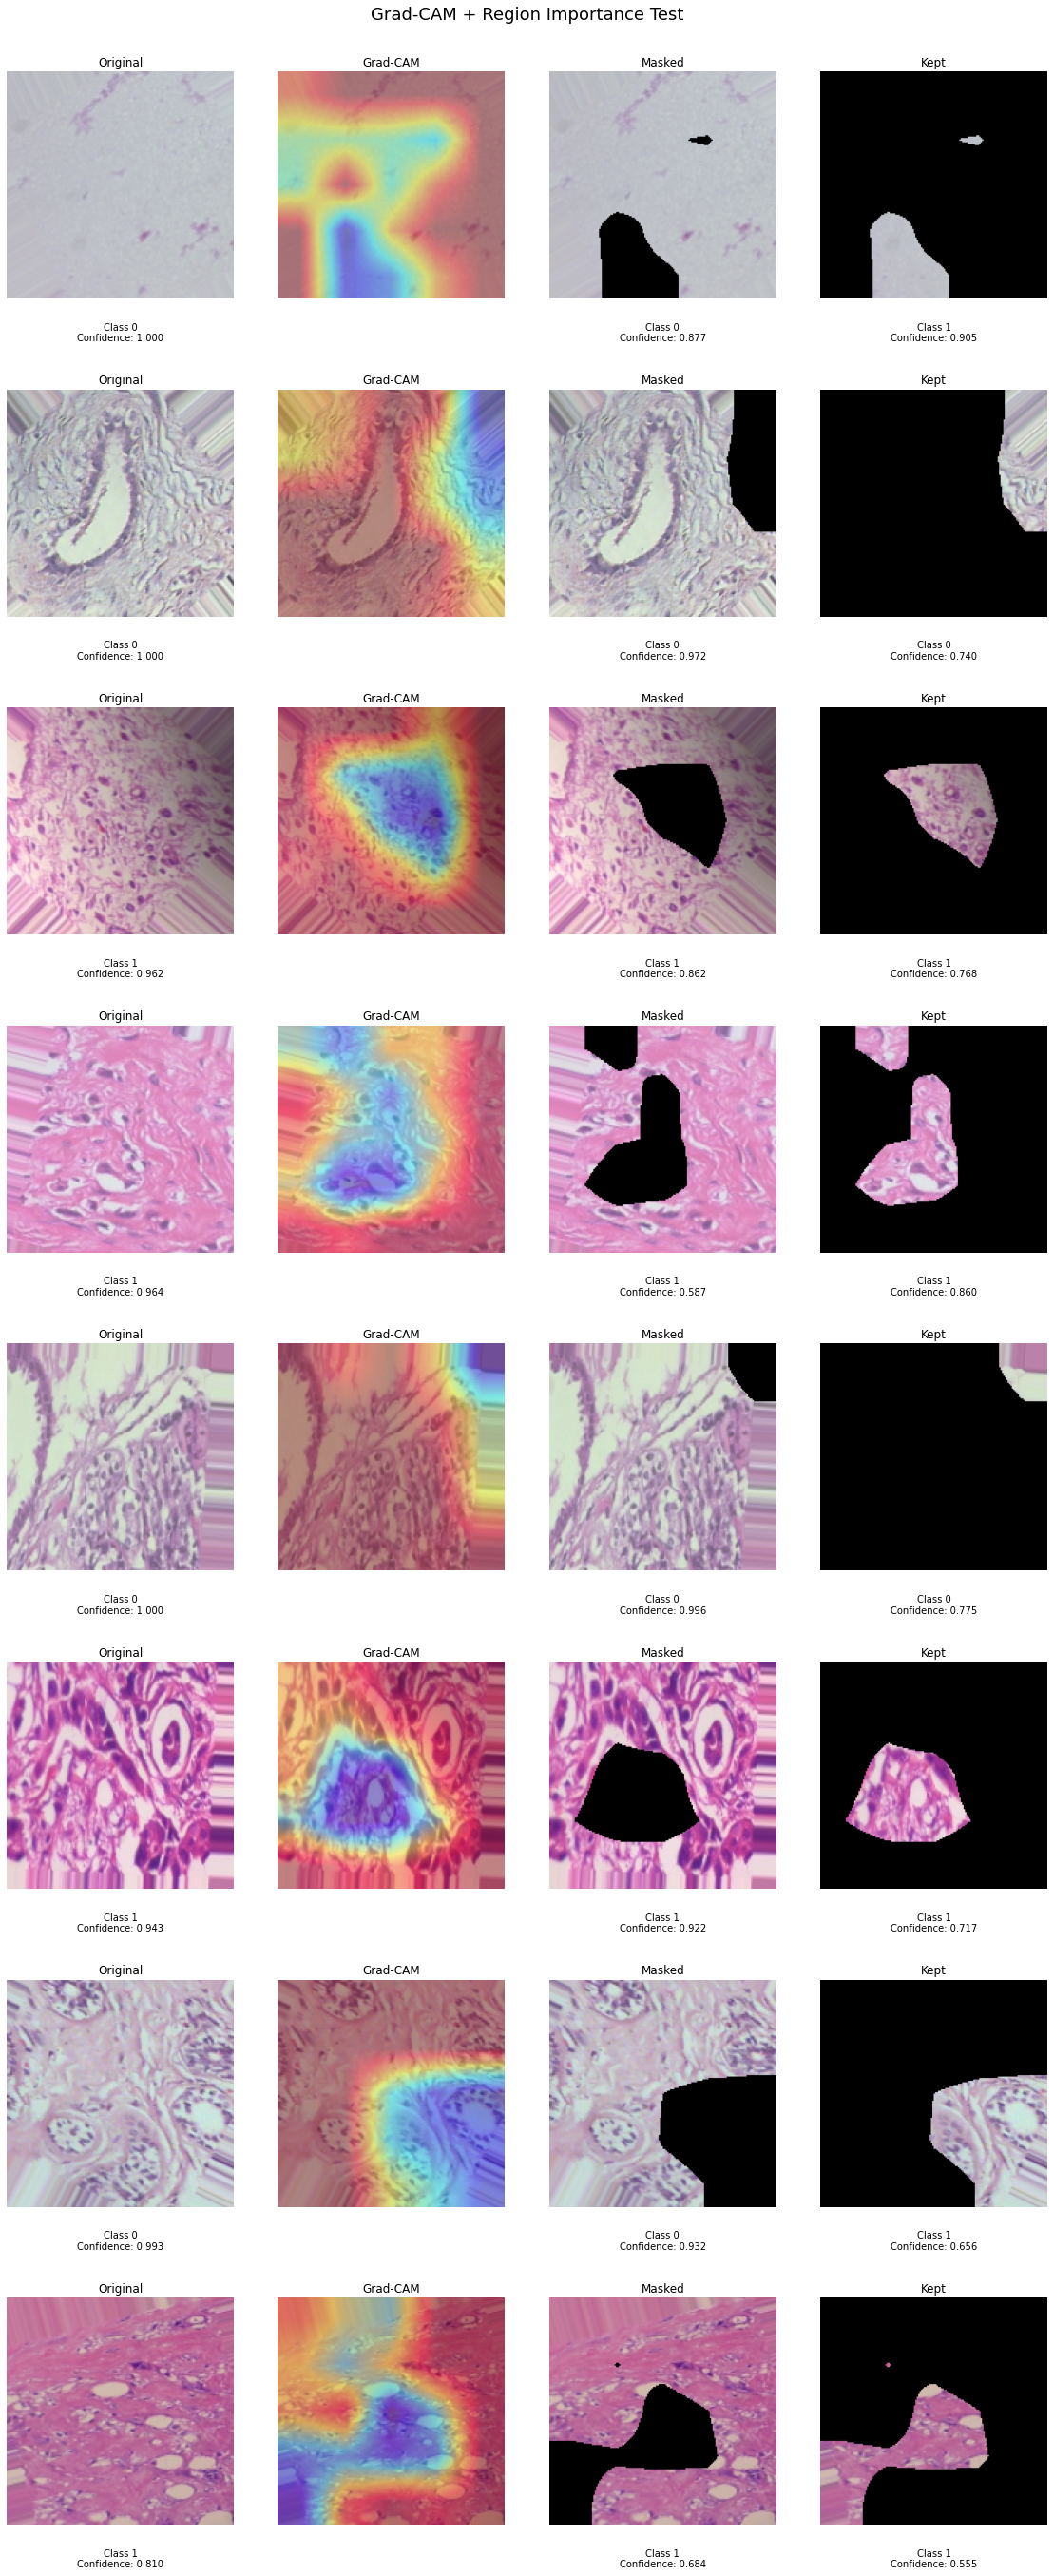

In [40]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

def apply_heatmap_mask(image, heatmap, mode='remove', threshold=0.6):
    """
    Apply mask to image based on heatmap values
    Args:
        image: Input image to be masked
        heatmap: Attention heatmap
        mode: 'remove' to zero out high attention regions, 'keep' to only keep high attention regions
        threshold: Threshold value for masking
    """
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    mask = heatmap > threshold

    if mode == 'remove':
        masked_image = np.copy(image)
        masked_image[mask] = 0  # Zero out high attention regions
    elif mode == 'keep':
        masked_image = np.zeros_like(image)
        masked_image[mask] = image[mask]  # Only keep high attention regions
    else:
        raise ValueError("mode must be 'remove' or 'keep'")
    return masked_image

# Select random samples for visualization
num_samples = 8
random_indices = np.random.choice(len(training_images), num_samples, replace=False)

# Create figure with increased height for titles
plt.figure(figsize=(16, num_samples * 5))

for i, idx in enumerate(random_indices):
    # Get and preprocess image
    image_array = training_images[idx:idx+1]
    original_img = (image_array[0] * 255).astype(np.uint8)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        model=hybrid_vit_spt,
        image_array=image_array,
        target_layer_name="top_conv"
    )
    overlay = overlay_heatmap(heatmap, original_img)

    # Generate masked images
    removed = apply_heatmap_mask(original_img, heatmap, mode='remove')
    kept = apply_heatmap_mask(original_img, heatmap, mode='keep')

    # Get model predictions
    def preprocess(img): return np.expand_dims(img.astype(np.float32) / 255.0, axis=0)
    pred_ori = hybrid_vit_spt.predict(image_array, verbose=0)[0]
    pred_rem = hybrid_vit_spt.predict(preprocess(removed), verbose=0)[0]
    pred_keep = hybrid_vit_spt.predict(preprocess(kept), verbose=0)[0]

    # Print prediction info for debugging
    print(f"\nSample #{idx}")
    print(f"Original     → class {np.argmax(pred_ori)} (score {np.max(pred_ori):.3f})")
    print(f"Masked (out) → class {np.argmax(pred_rem)} (score {np.max(pred_rem):.3f})")
    print(f"Kept (only)  → class {np.argmax(pred_keep)} (score {np.max(pred_keep):.3f})")

    # Plot original image
    ax1 = plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(original_img)
    plt.title("Original")
    plt.axis('off')
    plt.text(0.5, -0.15, f'Class {np.argmax(pred_ori)}\nConfidence: {np.max(pred_ori):.3f}', 
             ha='center', va='center', transform=ax1.transAxes, fontsize=10)

    # Plot Grad-CAM overlay
    ax2 = plt.subplot(num_samples, 4, i * 4 + 2)
    plt.imshow(overlay)
    plt.title("Grad-CAM")
    plt.axis('off')

    # Plot masked image
    ax3 = plt.subplot(num_samples, 4, i * 4 + 3)
    plt.imshow(removed)
    plt.title("Masked")
    plt.axis('off')
    plt.text(0.5, -0.15, f'Class {np.argmax(pred_rem)}\nConfidence: {np.max(pred_rem):.3f}', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=10)

    # Plot kept regions
    ax4 = plt.subplot(num_samples, 4, i * 4 + 4)
    plt.imshow(kept)
    plt.title("Kept")
    plt.axis('off')
    plt.text(0.5, -0.15, f'Class {np.argmax(pred_keep)}\nConfidence: {np.max(pred_keep):.3f}', 
             ha='center', va='center', transform=ax4.transAxes, fontsize=10)

# Adjust layout for better text visibility
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, bottom=0.1)
plt.suptitle("Grad-CAM + Region Importance Test", fontsize=18, y=1.02)
plt.show()

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import pandas as pd
from matplotlib.ticker import MaxNLocator
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12

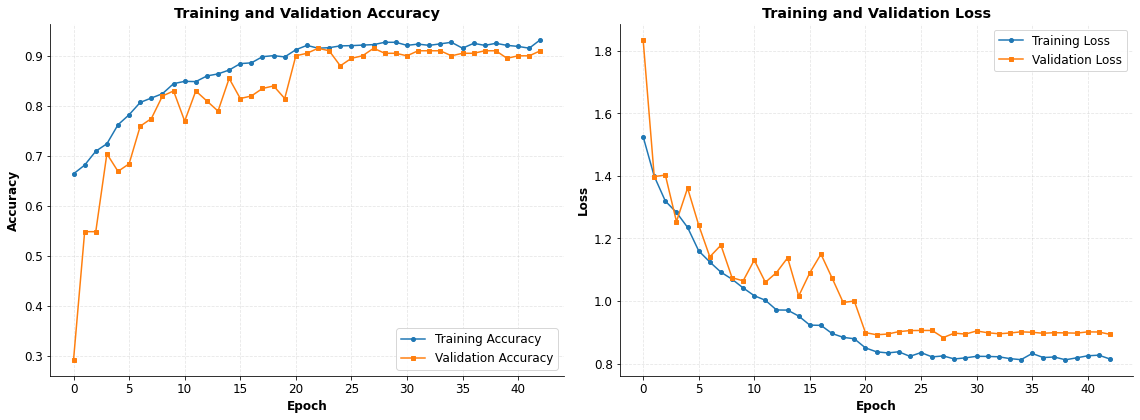

In [44]:
# Create results directory
import os
results_dir = '/root/autodl-tmp/results'
os.makedirs(results_dir, exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Set common properties
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)
    ax.tick_params(direction='out')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Accuracy curves
ax1.plot(history_spt.history['accuracy'], marker='o', markersize=4, linestyle='-', color='#1f77b4', label='Training Accuracy')
ax1.plot(history_spt.history['val_accuracy'], marker='s', markersize=4, linestyle='-', color='#ff7f0e', label='Validation Accuracy')
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Training and Validation Accuracy', fontweight='bold')
ax1.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# Loss curves
ax2.plot(history_spt.history['loss'], marker='o', markersize=4, linestyle='-', color='#1f77b4', label='Training Loss')
ax2.plot(history_spt.history['val_loss'], marker='s', markersize=4, linestyle='-', color='#ff7f0e', label='Validation Loss')
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Loss', fontweight='bold')
ax2.set_title('Training and Validation Loss', fontweight='bold')
ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

plt.tight_layout()
plt.savefig(f"{results_dir}/accuracy_loss_curves.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/accuracy_loss_curves.pdf", bbox_inches='tight')
plt.show()


In [46]:
# Evaluate model performance on test set
loss, accuracy = model_spt.evaluate(test_images, test_labels)
print(f"Test loss: {round(loss, 2)}")
print(f"Test accuracy: {round(accuracy * 100, 2)}%")

# Get model predictions
y_pred = model_spt.predict(test_images)

# Process labels and predictions
# Flatten test labels and get predicted class indices
rounded_test_labels = test_labels.flatten()
rounded_predictions = np.argmax(y_pred, axis=1)

# Get probability scores for positive class (for ROC curve)
y_pred_prob = y_pred[:, 1]

# Print detailed classification metrics
print("\nClassification Report:")
print(classification_report(rounded_test_labels, rounded_predictions, target_names=['Benign', 'Malignant']))

13/13 [==============================] - 1s 36ms/step - loss: 0.8672 - accuracy: 0.9160
Test loss: 0.87
Test accuracy: 91.6%
13/13 [==============================] - 0s 34ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.86      0.87       125
   Malignant       0.94      0.95      0.94       280

    accuracy                           0.92       405
   macro avg       0.91      0.90      0.90       405
weighted avg       0.92      0.92      0.92       405



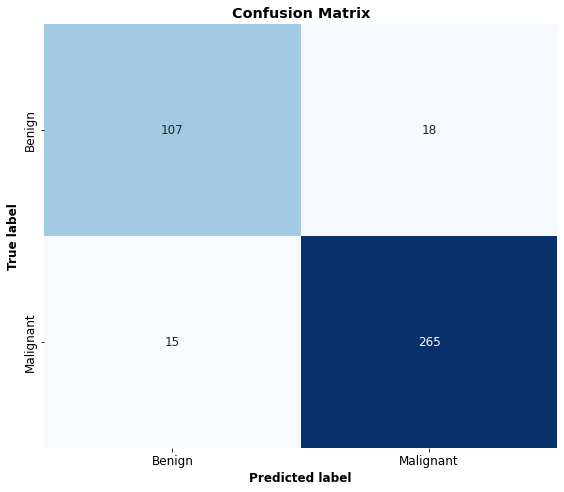

In [47]:
# Calculate confusion matrix from true labels and predictions
cm = confusion_matrix(rounded_test_labels, rounded_predictions)
classes = ['Benign', 'Malignant']

# Create confusion matrix heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=classes, yticklabels=classes)
plt.ylabel('True label', fontweight='bold')
plt.xlabel('Predicted label', fontweight='bold') 
plt.title('Confusion Matrix', fontweight='bold')

# Remove top and right borders for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Save and display plot
plt.tight_layout()
plt.savefig(f"{results_dir}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/confusion_matrix.pdf", bbox_inches='tight')
plt.show()

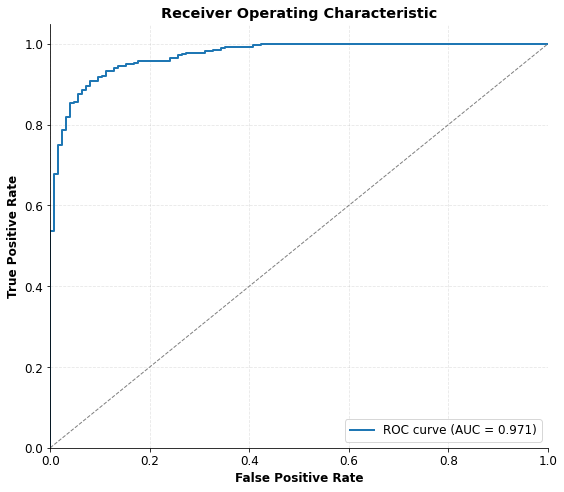

In [48]:
#------------------------------------------------
# 4. 绘制ROC曲线和计算AUC
#------------------------------------------------
fpr, tpr, thresholds = roc_curve(rounded_test_labels, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#1f77b4', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Receiver Operating Characteristic', fontweight='bold')
plt.legend(loc="lower right", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# 去除上边框和右边框
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{results_dir}/roc_curve.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/roc_curve.pdf", bbox_inches='tight')
plt.show()

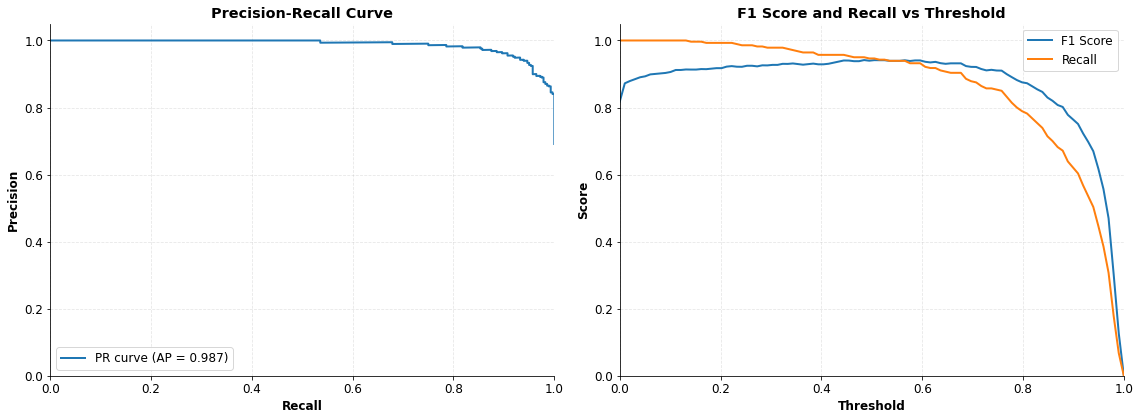

In [49]:
# Calculate precision-recall curve and average precision score
precision, recall, _ = precision_recall_curve(rounded_test_labels, y_pred_prob)
average_precision = average_precision_score(rounded_test_labels, y_pred_prob)

# Create subplots for PR curve and threshold analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Set common style for both plots
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)
    ax.tick_params(direction='out')

# Plot precision-recall curve
ax1.plot(recall, precision, color='#1f77b4', lw=2,
        label=f'PR curve (AP = {average_precision:.3f})')
ax1.set_xlabel('Recall', fontweight='bold')
ax1.set_ylabel('Precision', fontweight='bold')
ax1.set_title('Precision-Recall Curve', fontweight='bold')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.legend(loc="lower left", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# Calculate F1 score and recall for different thresholds
thresholds_list = np.linspace(0, 1, 100)
f1_scores = []
recall_scores = []

for threshold in thresholds_list:
    # Convert probabilities to binary predictions using threshold
    y_pred_binary = (y_pred_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(rounded_test_labels, y_pred_binary).ravel()
    
    # Calculate metrics
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    f1_scores.append(f1)
    recall_scores.append(rec)

# Plot F1 score and recall vs threshold
ax2.plot(thresholds_list, f1_scores, color='#1f77b4', lw=2, label='F1 Score')
ax2.plot(thresholds_list, recall_scores, color='#ff7f0e', lw=2, label='Recall')
ax2.set_xlabel('Threshold', fontweight='bold')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('F1 Score and Recall vs Threshold', fontweight='bold')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.legend(loc="best", frameon=True, facecolor='white', framealpha=0.9, edgecolor='lightgray')

# Save and display plots
plt.tight_layout()
plt.savefig(f"{results_dir}/precision_recall_f1.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{results_dir}/precision_recall_f1.pdf", bbox_inches='tight')
plt.show()

In [50]:

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall (Sensitivity)': recall,
    'F1 Score': f1,
    'Specificity': specificity,
    'AUC-ROC': roc_auc,
    'Average Precision': average_precision
}


print("\nEvaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


pd.DataFrame([metrics]).to_csv(f"{results_dir}/evaluation_metrics.csv", index=False)


Evaluation Metrics:
Accuracy: 0.9185
Precision: 0.9364
Recall (Sensitivity): 0.9464
F1 Score: 0.9414
Specificity: 0.8560
AUC-ROC: 0.9715
Average Precision: 0.9869
